In [1]:
from datasets import load_dataset
import numpy as np
from collections import Counter
import os

# temporary use of
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, IterableDataset

In [2]:
ds = load_dataset("afmck/text8") # https://huggingface.co/datasets/afmck/text8

## The Skip-gram Model
the objective of the Skip-gram model is to maximize the average log probability

$$
\frac{1}{T} \sum_{t=1}^{T} \sum_{\substack{-c \le j \le c,j \ne 0}} \log p(w_{t+j} \mid w_t)
$$
- $c$ is the size of the training context (which can be a function of the center word $w_{t}$)

### Softmax

The basic Skip-gram formulation defines $p(w_{t+j} \mid w_t)$ using the softmax function:

$$
p(w_O \mid w_I) = \frac{\exp\left({v'_{w_O}}^{\top} v_{w_I}\right)}{\sum_{w=1}^{W} \exp\left({v'_w}^{\top} v_{w_I}\right)}
$$
- $v_{w}$ and $v'_{w}$ are the “input” and “output” vector representations of $w$, and $W$ is the number of words in the vocabulary.<br>
- This formulation is impractical because the cost of computing $\nabla \log p(w_O \mid w_I)$ is proportional to $W$, which is often very large ($10^5$–$10^7$ terms).

### Hierarchical Softmax

Then the hierarchical softmax defines $p(w_O \mid w_I)$ as follows:

$$
p(w \mid w_I) = \prod_{j=1}^{L(w)-1} \sigma \left( [\!\left[ n(w, j+1) = ch(n(w, j)) \right]\!\right] \cdot {v'}_{n(w,j)}^{\top} v_{w_I} )
$$

- Let $n(w, j)$ be the $j$-th node on the path from the root to $w$
- let $L(w)$ be the length of this path, so $n(w, 1) = root$ and $n(w, L(w)) = w$
- $\sigma(x) = {1} / {(1 + \exp(-x))}$. It can be verified that $\sum_{w=1}^{W} p(w \mid w_I) = 1$
- let $ch(n)$ be an arbitrary fixed child of $n$
- let $ \left[\!\left[ x \right]\!\right] $ be 1 if $x$ is true and -1 otherwise

### Negative Sampling

An alternative to the hierarchical softmax is Noise Contrastive Estimation (NCE)

We define Negative sampling (NEG) by the objective 

$$
\log \sigma\left({v'}_{w_O}^{\top} v_{w_I}\right) + \sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n(w)} \left[ \log \sigma\left(-{v'}_{w_i}^{\top} v_{w_I}\right) \right]
$$

which is used to replace every $\log P (w_O | w_I )$ term in the Skip-gram objective

- values of k in the range 5–20 are useful for small training datasets
- for large datasets the k can be as small as 2–5

> The main difference between the Negative sampling and NCE is that NCE needs both samples and the numerical probabilities of the noise distribution, while Negative sampling uses only samples

#### Noise Distribution

Both NCE and NEG have the noise distribution $P_n(w)$ as a free parameter

- unigram distribution $U(w)$ raised to the 3/4rd power (i.e., $U(w)^{3/4}/Z$) outperformed significantly the unigram and the uniform distributions

### Subsampling of Frequent Words

To counter the imbalance between the rare and frequent words, we used a simple subsampling approach: each word $w_i$ in the training set is discarded with probability computed by the formula

$$
P(w_i) = 1 - \sqrt{ \frac{t}{f(w_i)} }
$$

- $f(w_i)$ is the frequency of word $w_i$
- $t$ is a chosen threshold, typically around $10^{-5}$

We chose this subsampling formula because it aggressively subsamples words whose frequency is greater than $t$ while preserving the ranking of the frequencies

In [3]:
def split_data(ds):
    train, test, validation = ds["train"], ds["test"], ds["validation"]
    split_text = lambda dataset: [x for x in dataset["text"][0].split() if x]
    train = split_text(train)
    test = split_text(test)
    validation = split_text(validation)
    return train, test, validation

train, test, validation = split_data(ds)

In [4]:
def subsampling(words, threshold=1e-5):
    counts = Counter(words)
    total_count = len(words)
    # P(w) = (sqrt(f(w)/t) + 1) * (t/f(w))
    new_words = []
    for w in words:
        freq = counts[w] / total_count
        p_keep = (np.sqrt(freq / threshold) + 1) * (threshold / freq)
        if np.random.random() < p_keep:
            new_words.append(w)
    return new_words

In [5]:
def create_unigram_table(word_counts, vocab, table_size=100_000_000):
    freqs = np.array([word_counts[w] for w in vocab])
    pow_freqs = freqs**0.75
    probs = pow_freqs / sum(pow_freqs)
    
    table = np.zeros(table_size, dtype=np.int32)
    count = 0
    for idx, p in enumerate(probs):
        n = int(p * table_size)
        table[count : count + n] = idx
        count += n
    return table

In [7]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed(42)

In [8]:
# Frequency of the words
full_counts = Counter(train)
# Discard words occured less than 5 times & subsamble
train = [w for w in train if full_counts[w] >= 5]
train = subsampling(train)

# Create alphabetic vocabulary
vocab = sorted(list(set(train)))
# word to index & index to word operations
word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: word for i, word in enumerate(vocab)}
vocab_size = len(vocab) # Vocabulary size

# Frequency of the words after discarding & subsampling
word_counts = {w: full_counts[w] for w in vocab}

# Unigram table for Negative Sampling
unigram_table = create_unigram_table(word_counts, vocab)

In [9]:
print(f'Sözlük Boyutu:        {vocab_size:,}')
print(f'Toplam kelime sayısı: {len(train):,}')

Sözlük Boyutu:        67,427
Toplam kelime sayısı: 4,999,119


In [10]:
class SkipGramDataset(IterableDataset):
    def __init__(self, data, word2idx, window_size=5):
        self.data = data
        self.word2idx = word2idx
        self.window_size = window_size

    def __iter__(self):
        for i, word in enumerate(self.data):
            target_idx = self.word2idx[word]

            window = np.random.randint(1, self.window_size + 1)

            start = max(0, i - window)
            end = min(len(self.data), i + window + 1)

            context_positions = [j for j in range(start, end) if j != i]

            if not context_positions:
                continue

            j = context_positions[np.random.randint(len(context_positions))]

            yield target_idx, self.word2idx[self.data[j]]

In [11]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.u_embeddings = nn.Embedding(vocab_size, emb_dim) # Center words
        self.v_embeddings = nn.Embedding(vocab_size, emb_dim) # Context & Negative words
        
        # Ağırlıkları başlatma
        init_range = 0.5 / emb_dim
        self.u_embeddings.weight.data.uniform_(-init_range, init_range)
        self.v_embeddings.weight.data.zero_()

    def forward(self, pos_u, pos_v, neg_v):
        # pos_u: [batch_size]
        # pos_v: [batch_size]
        # neg_v: [batch_size, k]

        emb_u = self.u_embeddings(pos_u)     # [batch, dim]
        emb_v = self.v_embeddings(pos_v)     # [batch, dim]
        emb_neg = self.v_embeddings(neg_v)   # [batch, k, dim]

        # Pozitif Skor: dot(u, v)
        # Her batch için tek tek nokta çarpımı
        pos_score = torch.sum(torch.mul(emb_u, emb_v), dim=1) 
        pos_score = torch.clamp(pos_score, max=10, min=-10) # Sayısal stabilite
        pos_loss = F.logsigmoid(pos_score)

        # Negatif Skor: u * neg_v^T
        # [batch, 1, dim] * [batch, dim, k] -> [batch, 1, k]
        neg_score = torch.bmm(emb_neg, emb_u.unsqueeze(2)).squeeze()
        neg_loss = torch.sum(F.logsigmoid(-neg_score), dim=1)

        return -(pos_loss + neg_loss).mean()

In [12]:
# --- Hiperparametreler ---
EMB_DIM = 512
BATCH_SIZE = 1024
K_NEG = 5 
LEARNING_RATE = 0.001
EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Hazırlık
model = SkipGramModel(vocab_size, EMB_DIM).to(DEVICE)
if os.path.exists("skipgram.pt"):
    model.load_state_dict(torch.load("skipgram.pt"))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE) # Word2Vec için Adam iyidir
dataset = SkipGramDataset(train, word2idx, window_size=5)
loader = DataLoader(dataset, batch_size=BATCH_SIZE)

In [46]:
print(f"Eğitim başlıyor... Cihaz: {DEVICE}")

for epoch in range(EPOCHS):
    total_loss = 0
    for i, (pos_u, pos_v) in enumerate(loader):
        # 1. Negatif örnekleri tablodan çek (Batch bazlı)
        # unigram_table: Daha önce oluşturduğumuz NumPy array
        neg_v = np.random.choice(unigram_table, size=(pos_u.size(0), K_NEG))
        
        # Verileri cihaza taşı
        pos_u = pos_u.to(DEVICE)
        pos_v = pos_v.to(DEVICE)
        neg_v = torch.from_numpy(neg_v).long().to(DEVICE)

        # 2. Forward & Loss
        loss = model(pos_u, pos_v, neg_v)

        # 3. Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Ara bilgilendirme
        if i % 1000 == 0:
            print(f"Epoch: {epoch}, Batch: {i}, Loss: {loss.item():.4f}")

    print(f"--- Epoch {epoch} bitti. Ortalama Loss: {total_loss/i:.4f} ---")

Eğitim başlıyor... Cihaz: cuda
Epoch: 0, Batch: 0, Loss: 1.6735
Epoch: 0, Batch: 1000, Loss: 1.8480
Epoch: 0, Batch: 2000, Loss: 1.8700
Epoch: 0, Batch: 3000, Loss: 1.6021
Epoch: 0, Batch: 4000, Loss: 1.7736
--- Epoch 0 bitti. Ortalama Loss: 1.7713 ---
Epoch: 1, Batch: 0, Loss: 1.7059
Epoch: 1, Batch: 1000, Loss: 1.8184
Epoch: 1, Batch: 2000, Loss: 1.8434
Epoch: 1, Batch: 3000, Loss: 1.7016
Epoch: 1, Batch: 4000, Loss: 1.8012
--- Epoch 1 bitti. Ortalama Loss: 1.7671 ---
Epoch: 2, Batch: 0, Loss: 1.7552
Epoch: 2, Batch: 1000, Loss: 1.8849
Epoch: 2, Batch: 2000, Loss: 1.7589
Epoch: 2, Batch: 3000, Loss: 1.6413
Epoch: 2, Batch: 4000, Loss: 1.8917
--- Epoch 2 bitti. Ortalama Loss: 1.7627 ---
Epoch: 3, Batch: 0, Loss: 1.7574
Epoch: 3, Batch: 1000, Loss: 1.9106


KeyboardInterrupt: 

In [45]:
torch.save(model.state_dict(), "skipgram.pt")

In [34]:
def vector(word):
    if word not in word2idx:
        return None
    return wv[word2idx[word]]

def find_closest_word(target_vector, top_k=5, exclude_words=[]):
    similarities = np.dot(wv, target_vector)
    sorted_indices = np.argsort(similarities)[::-1]
    
    results = []
    for idx in sorted_indices:
        word = idx2word[idx]
        if word not in exclude_words:
            results.append((word, similarities[idx]))
        if len(results) >= top_k:
            break
    return results

In [47]:
# Vektörleri modelden çek (Merkez vektörleri u_embeddings kullanılır)
word_vectors = model.u_embeddings.weight.data.cpu()

# Her vektörü kendi uzunluğuna böl (Normalization)
# Bu sayede nokta çarpımı doğrudan Cosine Similarity olur
norms = word_vectors.norm(p=2, dim=1, keepdim=True)
word_vectors = word_vectors / norms

# Kolay erişim için NumPy'a çevirebilirsin
wv = word_vectors.numpy()

In [58]:
king = vector("king")
man = vector("man")
woman = vector("woman")

queen = find_closest_word(king - man + woman, 25)
queen

[('king', np.float32(1.0497887)),
 ('woman', np.float32(0.8086363)),
 ('wittelsbach', np.float32(0.39650524)),
 ('theresia', np.float32(0.3863428)),
 ('monarch', np.float32(0.3842116)),
 ('crowned', np.float32(0.38340783)),
 ('yolande', np.float32(0.37832183)),
 ('carloman', np.float32(0.37656763)),
 ('plectrude', np.float32(0.37614948)),
 ('gerar', np.float32(0.37419444)),
 ('aradia', np.float32(0.37074327)),
 ('dowager', np.float32(0.3698705)),
 ('archduchess', np.float32(0.36853945)),
 ('abdicate', np.float32(0.3658024)),
 ('throne', np.float32(0.3611269)),
 ('prince', np.float32(0.35881394)),
 ('phine', np.float32(0.358078)),
 ('lobau', np.float32(0.35577196)),
 ('salic', np.float32(0.35445666)),
 ('ancestress', np.float32(0.35121125)),
 ('zadok', np.float32(0.34988332)),
 ('bertrada', np.float32(0.34731114)),
 ('murat', np.float32(0.346277)),
 ('plantagenet', np.float32(0.344707)),
 ('queen', np.float32(0.34321177))]

In [68]:
v = vector
find_closest_word(v("rome") - v("italy") + v("germany"), 3)

[('germany', np.float32(0.8603667)),
 ('rome', np.float32(0.80615604)),
 ('berlin', np.float32(0.3517264))]

In [71]:
v = vector
find_closest_word(v("tokyo") - v("japan") + v("turkey"),14)

[('turkey', np.float32(0.9788431)),
 ('tokyo', np.float32(0.7696776)),
 ('turkish', np.float32(0.41172716)),
 ('konya', np.float32(0.39242595)),
 ('pontus', np.float32(0.38891327)),
 ('anatolia', np.float32(0.36484775)),
 ('sanjaks', np.float32(0.35857028)),
 ('yeni', np.float32(0.35590953)),
 ('afyon', np.float32(0.3458997)),
 ('adnan', np.float32(0.33502415)),
 ('lausanne', np.float32(0.3291005)),
 ('zmir', np.float32(0.32904273)),
 ('balkan', np.float32(0.32421643)),
 ('ankara', np.float32(0.3204746))]

In [63]:
pairs = [
    ("turkey", "ankara"),
    ("france", "paris"),
    ("germany", "berlin"),
    ("japan", "tokyo"),
    ("italy", "rome")
]

selected_words = []
vectors_to_visualize = []

for country, capital in pairs:
    v_country = vector(country)
    v_capital = vector(capital)
    
    if v_country is not None and v_capital is not None:
        selected_words.extend([country, capital])
        vectors_to_visualize.extend([v_country, v_capital])

vectors_to_visualize = np.array(vectors_to_visualize)

In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors_to_visualize)

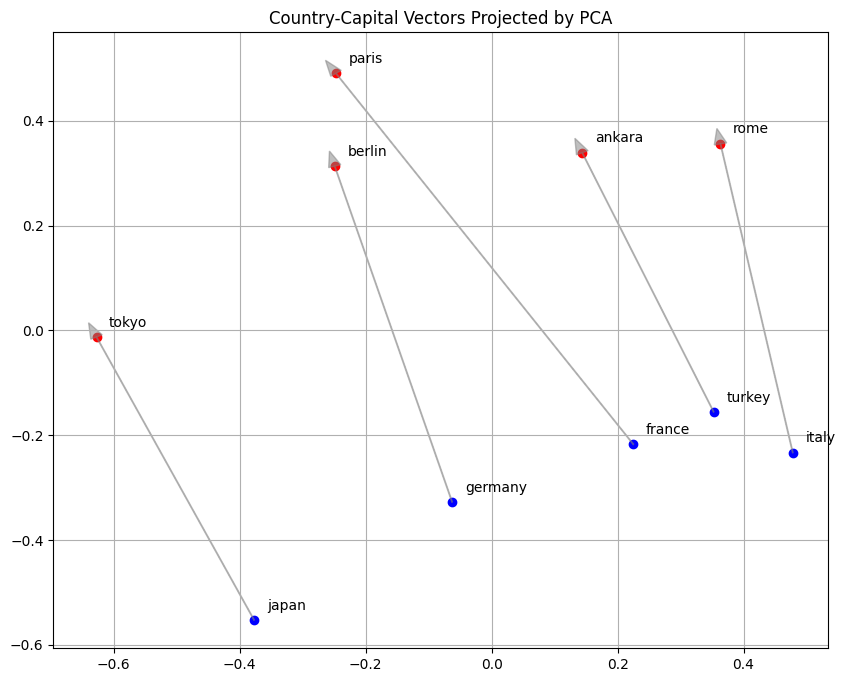

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for i in range(0, len(reduced_vectors), 2):
    country_vec = reduced_vectors[i]
    capital_vec = reduced_vectors[i+1]
    
    # Noktaları çiz
    plt.scatter(country_vec[0], country_vec[1], color='blue')
    plt.scatter(capital_vec[0], capital_vec[1], color='red')
    
    # Kelimeleri yaz
    plt.text(country_vec[0] + 0.02, country_vec[1] + 0.02, selected_words[i])
    plt.text(capital_vec[0] + 0.02, capital_vec[1] + 0.02, selected_words[i+1])
    
    # Aradaki ilişkiyi okla göster
    plt.arrow(country_vec[0], country_vec[1], 
              capital_vec[0] - country_vec[0], 
              capital_vec[1] - country_vec[1], 
              color='gray', alpha=0.5, head_width=0.02)

plt.title("Country-Capital Vectors Projected by PCA")
plt.grid(True)
plt.show()